## Import

In [34]:
import numpy as np
from itertools import product
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import SearchForPatterns as sfp

## Global

### Paths

In [10]:
#paths for the data that will be generated
root = "./data"
patterns_path = root + "/patterns"
trajectories_path = root + "/trajectories"
pinned_trajectories_path = root + "/pinned_trajectories"
patterns_1D_path = root + "/patterns/1D"
patterns_1D_space_path = root + "/patterns/1D/space" # for patterns along the 1D space at a single time step
patterns_1D_time_path = root + "/patterns/1D/time" # for patterns along the time axis at a single space cell
patterns_2D_path = root + "/patterns/2D" # means we have both space and time dimensions for 1D CAs


### Variables

In [11]:
# global CA parameters
width = 5 # width of the 1D cellular automaton
n_steps = 2**width # number of steps to simulate
initial_states = [np.array(bits) for bits in product([0, 1], repeat=width)] # all possible initial states
rules = [30, 45, 73, 110, 150, 105, 54, 22, 60, 146, 126, 62, 90, 18, 122, 26, 154, 94, 41, 57, 156, 28, 58, 78,
            178, 77, 50, 13, 25, 37, 9, 35, 106, 3, 27, 43, 184, 56, 11, 142, 14, 134, 24, 7, 152, 170, 46, 15, 33,
            1, 42, 162, 6, 5, 138, 38, 10, 74, 34, 29, 130, 2, 204, 200, 172, 108, 76, 72, 51, 44, 104, 232, 140, 132,
            23, 12, 164, 36, 19, 4, 168, 40, 160, 136, 128, 32, 8, 0]

### Loading the patterns

In [13]:
# assumed generation parameters
test_width_1D = 5
test_height_1D = 5

# load the patter of 1D space
with open(patterns_1D_space_path + f"/all_pattern_counts_{width}_{test_width_1D}_1_1_1", "rb") as f:
    patterns_1D_space = pickle.load(f)

# load the pattern of 1D time
with open(patterns_1D_time_path + f"/all_pattern_counts_{width}_1_{test_height_1D}_1_1", "rb") as f:
    patterns_1D_time = pickle.load(f)

# load the pattern of 2D
test_width_2D = 3
test_height_2D = 3
with open(patterns_2D_path + f"/all_pattern_counts_{width}_{test_width_2D}_{test_height_2D}_1_1", "rb") as f:
    patterns_2D = pickle.load(f)


## Utility

### Convert a string looking like an array of bits to an actual array

In [61]:
def bitstring_to_array(s: str) -> np.ndarray:
    """
    Convert a string with 0s and 1s to a numpy array of integers (0s and 1s)
    Args:
        s: string with 0s and 1s
    Returns:
        numpy array with 0s and 1s
    """
    return np.array([int(c) for c in s if c in "01"])

#### Example

In [64]:
print(bitstring_to_array("01010101"))
print(bitstring_to_array("sgr0sgr1sgr0sgr1"))

[0 1 0 1 0 1 0 1]
[0 1 0 1]


### Custom Pie Chart patches in matplotlib

In [88]:
# Function to draw pie chart in the given matplotlib axis
def draw_pie(_ax, _ratios,
             _X=0, _Y=0, _size=1, 
             _colors=['red', 'blue', 'green', 'orange'],
             _lines=True):
    """
    Draw a pie chart on a given matplotlib axis.

    Args:
        ax (matplotlib.axes.Axes): The axis to draw the pie chart on.
        ratios (list of float): The ratios for the pie chart. Should sum to 1 or less.
        X (float): The x-coordinate of the center of the pie chart.
        Y (float): The y-coordinate of the center of the pie chart.
        size (float): The radius of the pie chart.
        colors (list of str): The colors for the pie chart segments.
        lines (bool): Whether to draw lines from the center of the pie chart to the segments.
    """
    # Warn if the sum of ratio is bigger than 1
    if sum(_ratios) > 1:
        print("[draw_pie] Warning: sum of ratios is bigger than 1")

    # Adapt the colors to the number of ratios by cycling through the colors
    colors = _colors
    if len(_colors) < len(_ratios):
        n = len(_ratios) // len(_colors) + 1
        colors = _colors * n

    start_angle = 0
    for r, c in zip(_ratios, colors):
        end_angle = start_angle + r * 360
        wedge = patches.Wedge((_X, _Y), _size, start_angle, end_angle, facecolor=c)
        _ax.add_patch(wedge)
        if _lines:
            _ax.plot([_X, _X + _size * np.cos(np.radians(start_angle))], [_Y, _Y + _size * np.sin(np.radians(start_angle))], color='black', lw=0.5)
        start_angle = end_angle

#### Example

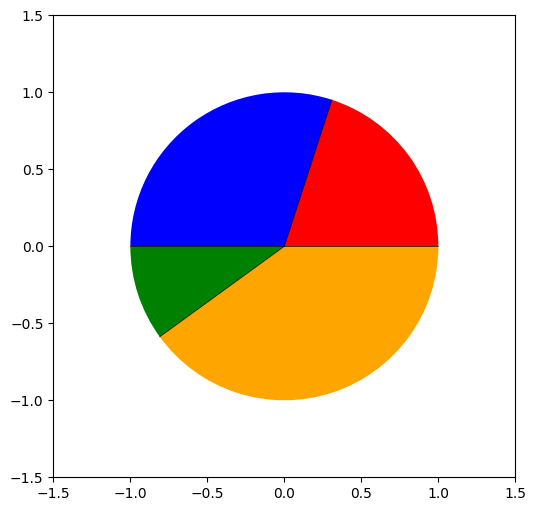

In [89]:
# Drawing a pie chart using draw_pie

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Define the ratios for the pie chart
ratios = [0.2, 0.3, 0.1, 0.4]

# Draw the pie chart
draw_pie(ax, ratios,
         _X=0, _Y=0, _size=1,
         _colors=['red', 'blue', 'green', 'orange'],
         _lines=True)

# Set the limits and aspect ratio
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

# Display the plot
plt.show()


### Scatter plot of pie charts

In [48]:
def scatter_pies(_ax, _xData, _yData, _ratios,
                 _size=1, _colors=['red', 'blue', 'green', 'orange'], _lines=True):
    """
    Scatter plot with pie charts for each point.

    Args:
        _ax (matplotlib.axes.Axes): The axis to draw the scatter plot on.
        _xData (list of float): The x-coordinates of the points.
        _yData (list of float): The y-coordinates of the points.
        _pies (list of list of float): The pie charts for each point.
        _size (float): The size of the pie charts.
        _colors (list of str): The colors for the pie chart segments.
        _lines (bool): Whether to draw lines from the center of the pie chart to
            the segments.
    """

    # Warning if the number of points and pies do not match
    if len(_xData) != len(_yData) or len(_xData) != len(_ratios):
        print("[scatter_pies] Warning: number of points and pies do not match")
        print(f"[scatter_pies] xData: {len(_xData)}, yData: {len(_yData)}, pies: {len(_ratios)}")
        print("[scatter_pies] Ignoring the extra points or pies")

    for x, y, rs in zip(_xData, _yData, _ratios):
        draw_pie(_ax, rs, _X=x, _Y=y, _size=_size, _colors=_colors, _lines=_lines)

#### Example

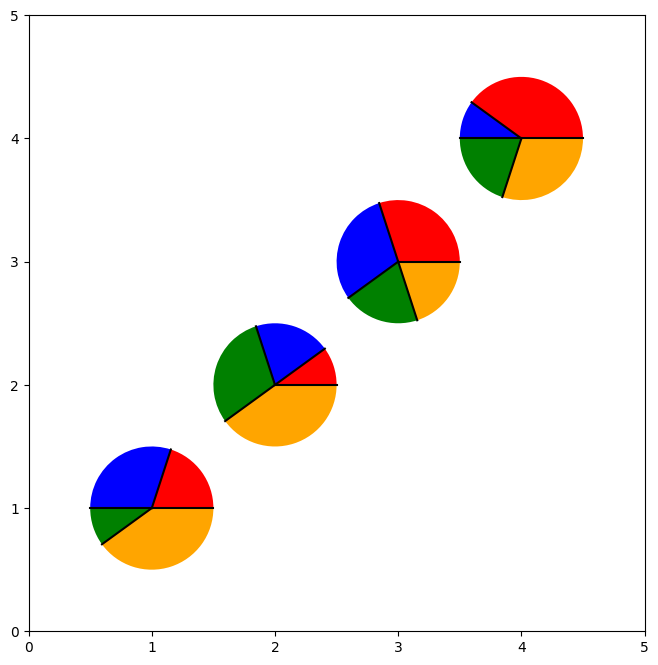

In [49]:
# Example data for scatter_pies
xData = [1, 2, 3, 4]
yData = [1, 2, 3, 4]
pies = [
    [0.2, 0.3, 0.1, 0.4],
    [0.1, 0.2, 0.3, 0.4],
    [0.3, 0.3, 0.2, 0.2],
    [0.4, 0.1, 0.2, 0.3]
]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

# Use scatter_pies to plot the data
scatter_pies(ax, xData, yData, pies,
             _size=0.5, _colors=['red', 'blue', 'green', 'orange'], _lines=True)

# Set the limits and aspect ratio
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect('equal')

# Display the plot
plt.show()

## Descriptive analysis

### Distribution of patterns per rule

- Which rule/IC have the low diversity of pattern (with expected high count)? (i.e. creates a very uniform trajectory)
- Conversely, which rule/IC have the highest diversity of pattern (with expected low count)? (i.e. creates very diverse trajectory)

We can answer these questions by ploting a scatter of pie charts: 
- One pie chart per position (rule/IC)
- the color of the pie chart is the number of non-zero integer in the pattern array of the rule (i.e. number of patterns). Following thermometter gradient.
- the area of the pie chart in the plot is the sum of all pattern occurrences (i.e. the population of patterns in the rule)
- the pie chart's parts are the count of each pattern in the total count (i.e. the weight of each pattern in the diversity of the population)

In [26]:
# Alias variable for the target data
patternsData = patterns_1D_space

# Alias variables for the window
windowWidth = test_width_1D
windowHeight = 1
patternWindow = sfp.PatternScanWindow(windowWidth, windowHeight)

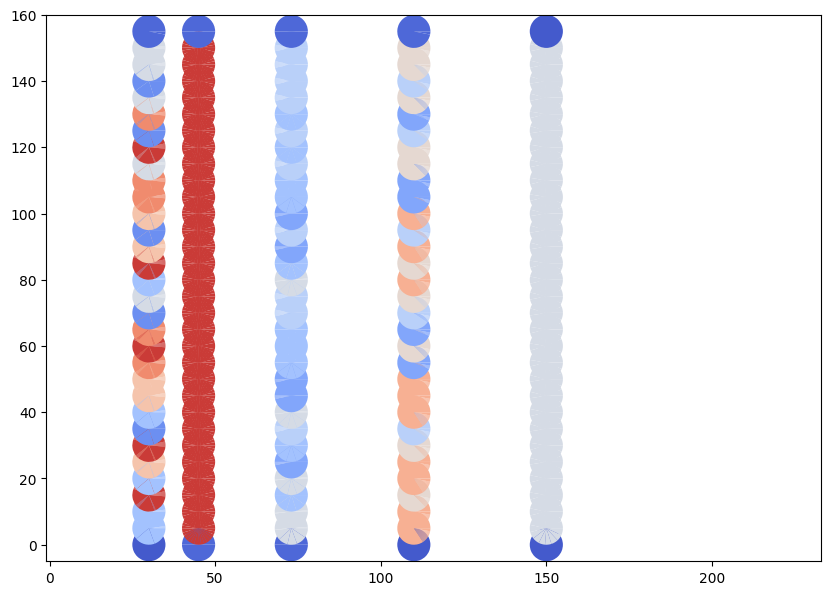

In [96]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 20))

# Define a colormap for the pie chart colors
colormap = plt.colormaps['coolwarm']

# utility plotting variables to scale the space between the pies and increase readability
x_offset = 1
y_offset = 5

# Iterate over the rules and initial conditions
for rule in rules[:5]:  # truncating for testing
    x = x_offset * rule

    for ic, patternsCount in patternsData[rule].items():
        y = y_offset*patternWindow.CA_2D_State_To_Integer(bitstring_to_array(ic))

        # Calculate the total population (sum of all pattern occurrences)
        total_population = sum(patternsCount)

        # Calculate the number of non-zero patterns
        non_zero_patterns = sum(1 for count in patternsCount if count != 0)

        # Normalize the pattern counts to get the ratios for the pie chart
        ratios = [count / total_population for count in patternsCount if count != 0]

        # Get the colors for the pie chart segments
        colors = [colormap(non_zero_patterns/patternsCount.shape[0])[:3] for i in range(non_zero_patterns)]

        # Draw the pie chart
        #print(f"Rule: {rule}, IC: {ic}, X: {x}, Y: {y}, Ratios: {ratios}, Colors: {colors}")
        draw_pie(ax, ratios, _X=x, _Y=y, _size=5, _colors=colors, _lines=False)

# Set the limits and aspect ratio
ax.set_xlim(-1 * x_offset, x_offset * np.max(rules) + 1)
ax.set_ylim(-1 * y_offset, y_offset * 2**width)
ax.set_aspect('equal')

# Display the plot
plt.show()